
# NB-03 · MoCo v3 + SegFormer-B0  
## Brain Tumour MRI Binary Semantic Segmentation from COCO Polygons

**Course:** CSE 438: Digital Image Processing  
**Course Instructor:** Dr Md Rifat Ahmmad Rashid  
**Department:** Department of Computer Science and Engineering  
**Institution:** East West University (EWU)

---

### Learning objective

This notebook implements a transformer-based self-supervised segmentation pipeline in two stages:

1. **MoCo v3 pretraining:** the SegFormer MiT-B0 encoder learns from two augmented MRI views through an online branch and a momentum target branch.
2. **SegFormer fine-tuning:** the same MoCo v3-trained MiT-B0 encoder is transferred directly into `SegformerForSemanticSegmentation` for binary tumour-mask prediction.

The source annotations are stored as COCO polygons. For semantic segmentation, all tumour polygons belonging to an image are merged into a single binary mask:

\[
0=\text{background}, \qquad 1=\text{tumour region}.
\]

### Methodological distinction

Unlike the original queue-based MoCo formulation, **MoCo v3** adopts an online encoder, a prediction MLP, and a momentum-updated target encoder with in-batch contrastive comparisons. Since the downstream model is SegFormer, self-supervised pretraining is performed on the **MiT-B0 encoder itself**, not on an unrelated convolutional backbone.

### Computational safety

The notebook uses standard contiguous tensors only. Before training, an executable CUDA kernel test determines whether GPU execution is safe. AMP is enabled only after that test succeeds. MoCo v3 similarity matrices and cross-entropy are calculated explicitly in `float32`.



## Workflow

\[
\text{MRI images}
\longrightarrow
\text{two augmentations}
\longrightarrow
\begin{cases}
\text{online MiT-B0 + projector + predictor} \\
\text{momentum target MiT-B0 + projector}
\end{cases}
\longrightarrow
\text{MoCo v3 contrastive loss}
\]

\[
\text{trained online MiT-B0 encoder}
\longrightarrow
\text{SegFormer-B0 segmentation model}
\longrightarrow
\text{binary tumour probability map}
\longrightarrow
\text{tumour mask}
\]


In [1]:

# ============================================================
# 1. Imports, experiment configuration, and output folders
# ============================================================

from pathlib import Path
from contextlib import nullcontext
import copy
import json
import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle
from PIL import Image, ImageDraw

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms as T
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

from transformers import (
    SegformerConfig,
    SegformerModel,
    SegformerForSemanticSegmentation,
)

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)

# ------------------------------------------------------------
# Required Kaggle dataset location.
# ------------------------------------------------------------
DATA_ROOT = Path("/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation")

# ------------------------------------------------------------
# Every generated result is saved in /kaggle/working/.
# ------------------------------------------------------------
OUTPUT_DIR = Path("/kaggle/working/mocov3_segformer_brain_tumour")
FIGURE_DIR = OUTPUT_DIR / "figures"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
METRIC_DIR = OUTPUT_DIR / "metrics"

for directory in [OUTPUT_DIR, FIGURE_DIR, CHECKPOINT_DIR, METRIC_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Reproducibility and training configuration.
# ------------------------------------------------------------
SEED = 438
IMAGE_SIZE = 224
NUM_CLASSES = 2
MOCO_EPOCHS = 10
SEGMENTATION_EPOCHS = 10
NUM_WORKERS = 2

MIT_MODEL_ID = "nvidia/mit-b0"
LOAD_PRETRAINED_MIT_WHEN_AVAILABLE = True

MOCO_PROJECTION_DIM = 256
MOCO_MLP_HIDDEN_DIM = 1024
MOCO_MOMENTUM_BASE = 0.99
MOCO_TEMPERATURE = 0.20
MOCO_LR = 2e-4
SEGMENTATION_LR = 2e-4
WEIGHT_DECAY = 1e-4

def seed_everything(seed=SEED):
    """Make dataset order and parameter initialisation reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        try:
            torch.cuda.manual_seed_all(seed)
        except Exception:
            pass

seed_everything()

print(f"Dataset root: {DATA_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Torch version: {torch.__version__}")


Dataset root: /kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation
Output directory: /kaggle/working/mocov3_segformer_brain_tumour
Torch version: 2.10.0+cu128


In [2]:

# ============================================================
# 2. CUDA compatibility probe and conditional AMP support
# ============================================================

def select_safe_device():
    """
    A visible Kaggle GPU is not sufficient evidence that Torch kernels can run
    on it. This probe executes a convolution and backward pass before CUDA and
    AMP are accepted for the experiment.
    """
    if not torch.cuda.is_available():
        print("CUDA is unavailable. CPU mode selected; AMP is disabled.")
        return torch.device("cpu"), False

    try:
        probe_input = torch.randn(2, 3, 32, 32, device="cuda", requires_grad=True)
        probe_layer = nn.Conv2d(3, 6, kernel_size=3, padding=1).to("cuda")
        probe_loss = probe_layer(probe_input).square().mean()
        probe_loss.backward()
        torch.cuda.synchronize()

        print(f"CUDA probe passed on {torch.cuda.get_device_name(0)}.")
        print("CUDA mode selected; AMP is enabled for model forward passes.")
        return torch.device("cuda"), True
    except Exception as error:
        print("CUDA is visible but executable kernel validation failed.")
        print(f"Diagnostic message: {type(error).__name__}: {error}")
        print("CPU fallback selected; AMP is disabled.")
        return torch.device("cpu"), False

DEVICE, AMP_ENABLED = select_safe_device()

def autocast_context():
    """Use autocast only for validated CUDA execution."""
    if not AMP_ENABLED:
        return nullcontext()
    try:
        return torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=True)
    except AttributeError:
        return torch.cuda.amp.autocast(dtype=torch.float16, enabled=True)

def disable_autocast_for_contrastive(tensor):
    """Keep MoCo v3 similarity logits and loss in float32 under CUDA AMP."""
    if not tensor.is_cuda:
        return nullcontext()
    try:
        return torch.amp.autocast(device_type="cuda", enabled=False)
    except AttributeError:
        return torch.cuda.amp.autocast(enabled=False)

def create_grad_scaler():
    """Support both current and older Torch AMP interfaces used in Kaggle images."""
    try:
        return torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

# Moderate batches support BatchNorm in the MoCo v3 projection/prediction heads.
MOCO_BATCH_SIZE = 16 if DEVICE.type == "cuda" else 4
SEGMENTATION_BATCH_SIZE = 6 if DEVICE.type == "cuda" else 2
PIN_MEMORY = DEVICE.type == "cuda"

print(f"Device: {DEVICE}")
print(f"AMP enabled: {AMP_ENABLED}")
print(f"MoCo v3 batch size: {MOCO_BATCH_SIZE}")
print(f"Segmentation batch size: {SEGMENTATION_BATCH_SIZE}")


CUDA probe passed on Tesla T4.
CUDA mode selected; AMP is enabled for model forward passes.
Device: cuda
AMP enabled: True
MoCo v3 batch size: 16
Segmentation batch size: 6



## COCO polygon conversion

Each annotation may contain one or more polygon lists. The following data pipeline fills every valid polygon with foreground value `1`. When an image contains several tumour polygons, they are merged by writing all polygons into the same mask. Spatial augmentation is applied identically to the MRI and the mask during supervised fine-tuning.


In [3]:

# ============================================================
# 3. COCO parsing, polygon rasterisation, and dataset classes
# ============================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
NORMALISE = T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

def load_coco_records(split_directory: Path):
    """Read COCO image entries and associate each image with all polygon annotations."""
    annotation_path = split_directory / "_annotations.coco.json"
    if not annotation_path.exists():
        raise FileNotFoundError(f"Annotation file not found: {annotation_path}")

    with open(annotation_path, "r", encoding="utf-8") as file:
        coco_data = json.load(file)

    annotations_by_image = {}
    for annotation in coco_data.get("annotations", []):
        annotations_by_image.setdefault(annotation["image_id"], []).append(annotation)

    records = []
    for image_entry in coco_data.get("images", []):
        image_path = split_directory / image_entry["file_name"]
        if not image_path.exists():
            basename_candidate = split_directory / Path(image_entry["file_name"]).name
            image_path = basename_candidate if basename_candidate.exists() else image_path

        if image_path.exists():
            records.append({
                "image_id": image_entry["id"],
                "image_path": image_path,
                "file_name": image_entry["file_name"],
                "annotations": annotations_by_image.get(image_entry["id"], []),
            })

    if not records:
        raise RuntimeError(f"No readable images could be located in {split_directory}.")
    return records

def rasterise_binary_mask(image_size, annotations):
    """
    Convert polygon-level COCO annotations into one binary semantic mask:
      0 -> background
      1 -> tumour region
    """
    mask = Image.new("L", image_size, color=0)
    draw = ImageDraw.Draw(mask)

    for annotation in annotations:
        polygon_groups = annotation.get("segmentation", [])
        if not isinstance(polygon_groups, list):
            raise ValueError("This notebook expects COCO polygon segmentations, not RLE masks.")

        for polygon in polygon_groups:
            if len(polygon) < 6:
                continue
            coordinates = [
                (float(polygon[index]), float(polygon[index + 1]))
                for index in range(0, len(polygon) - 1, 2)
            ]
            draw.polygon(coordinates, outline=1, fill=1)

    return mask

class SegmentationPairTransform:
    """Transform MRI and binary mask together without corrupting discrete mask labels."""
    def __init__(self, training=False, size=IMAGE_SIZE):
        self.training = training
        self.size = size

    def __call__(self, image, mask):
        if self.training:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            if random.random() < 0.20:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

            angle = random.uniform(-10.0, 10.0)
            image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR, fill=0)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST, fill=0)

        image = TF.resize(image, [self.size, self.size], interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.size, self.size], interpolation=InterpolationMode.NEAREST)

        image_tensor = NORMALISE(TF.to_tensor(image)).contiguous()
        mask_array = np.asarray(mask, dtype=np.int64).copy()
        mask_tensor = torch.from_numpy((mask_array > 0).astype(np.int64)).long().contiguous()
        return image_tensor, mask_tensor

class COCOSemanticDataset(Dataset):
    """Supervised dataset used during SegFormer fine-tuning and evaluation."""
    def __init__(self, split_directory, training=False):
        self.records = load_coco_records(Path(split_directory))
        self.transform = SegmentationPairTransform(training=training)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        record = self.records[index]
        image = Image.open(record["image_path"]).convert("RGB")
        mask = rasterise_binary_mask(image.size, record["annotations"])
        image_tensor, mask_tensor = self.transform(image, mask)
        return image_tensor, mask_tensor, record["file_name"]

# MoCo v3 obtains two independently modified views of the same unlabelled MRI.
MOCO_AUGMENT = T.Compose([
    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.50, 1.0), interpolation=InterpolationMode.BILINEAR),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomApply([T.ColorJitter(brightness=0.25, contrast=0.25)], p=0.75),
    T.RandomGrayscale(p=0.15),
    T.RandomApply([T.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5))], p=0.30),
    T.ToTensor(),
    NORMALISE,
])

class MoCoV3TwoViewDataset(Dataset):
    """Unlabelled pretraining view: annotations are deliberately not requested."""
    def __init__(self, split_directory):
        self.records = load_coco_records(Path(split_directory))

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        image = Image.open(self.records[index]["image_path"]).convert("RGB")
        view_one = MOCO_AUGMENT(image).contiguous()
        view_two = MOCO_AUGMENT(image).contiguous()
        return view_one, view_two


In [4]:

# ============================================================
# 4. Construct datasets, DataLoaders, and inspect mask prevalence
# ============================================================

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"The dataset was not found at {DATA_ROOT}. "
        "Attach the specified Kaggle dataset before running this notebook."
    )

TRAIN_DIR = DATA_ROOT / "train"
VALID_DIR = DATA_ROOT / "valid"
TEST_DIR = DATA_ROOT / "test"

train_dataset = COCOSemanticDataset(TRAIN_DIR, training=True)
train_display_dataset = COCOSemanticDataset(TRAIN_DIR, training=False)
valid_dataset = COCOSemanticDataset(VALID_DIR, training=False)
test_dataset = COCOSemanticDataset(TEST_DIR, training=False)
moco_dataset = MoCoV3TwoViewDataset(TRAIN_DIR)

loader_settings = dict(
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

train_loader = DataLoader(
    train_dataset, batch_size=SEGMENTATION_BATCH_SIZE, shuffle=True,
    drop_last=False, **loader_settings
)
valid_loader = DataLoader(
    valid_dataset, batch_size=SEGMENTATION_BATCH_SIZE, shuffle=False,
    drop_last=False, **loader_settings
)
test_loader = DataLoader(
    test_dataset, batch_size=SEGMENTATION_BATCH_SIZE, shuffle=False,
    drop_last=False, **loader_settings
)
feature_loader = DataLoader(
    valid_dataset, batch_size=SEGMENTATION_BATCH_SIZE, shuffle=False,
    drop_last=False, **loader_settings
)

# drop_last=True is required for stable MoCo v3 mini-batches and BatchNorm heads.
moco_loader = DataLoader(
    moco_dataset, batch_size=MOCO_BATCH_SIZE, shuffle=True,
    drop_last=True, **loader_settings
)

if len(moco_loader) == 0:
    raise RuntimeError("MoCo v3 loader is empty. Reduce MOCO_BATCH_SIZE while retaining drop_last=True.")

print(f"Training images:   {len(train_dataset)}")
print(f"Validation images: {len(valid_dataset)}")
print(f"Test images:       {len(test_dataset)}")
print(f"MoCo v3 mini-batches per epoch: {len(moco_loader)}")

def measure_mask_distribution(dataset, split_name):
    """Quantify class imbalance resulting from foreground tumour occupancy."""
    tumour_pixels = 0
    tumour_images = 0
    total_pixels = 0

    for _, mask, _ in tqdm(dataset, desc=f"Analysing {split_name} masks", leave=False):
        foreground = int(mask.sum().item())
        tumour_pixels += foreground
        tumour_images += int(foreground > 0)
        total_pixels += int(mask.numel())

    return {
        "split": split_name,
        "images": len(dataset),
        "images_with_tumour": tumour_images,
        "tumour_images_percent": 100.0 * tumour_images / max(1, len(dataset)),
        "tumour_pixels_percent": 100.0 * tumour_pixels / max(1, total_pixels),
    }

mask_statistics = pd.DataFrame([
    measure_mask_distribution(train_display_dataset, "train"),
    measure_mask_distribution(valid_dataset, "valid"),
    measure_mask_distribution(test_dataset, "test"),
])
mask_statistics.to_csv(METRIC_DIR / "mask_distribution.csv", index=False)
mask_statistics


Training images:   1502
Validation images: 429
Test images:       215
MoCo v3 mini-batches per epoch: 93


Analysing train masks:   0%|          | 0/1502 [00:00<?, ?it/s]

Analysing valid masks:   0%|          | 0/429 [00:00<?, ?it/s]

Analysing test masks:   0%|          | 0/215 [00:00<?, ?it/s]

,split,images,images_with_tumour,tumour_images_percent,tumour_pixels_percent
0,train,1502,1501,99.933422,3.710254
1,valid,429,429,100.000000,3.721827
2,test,215,215,100.000000,3.716379


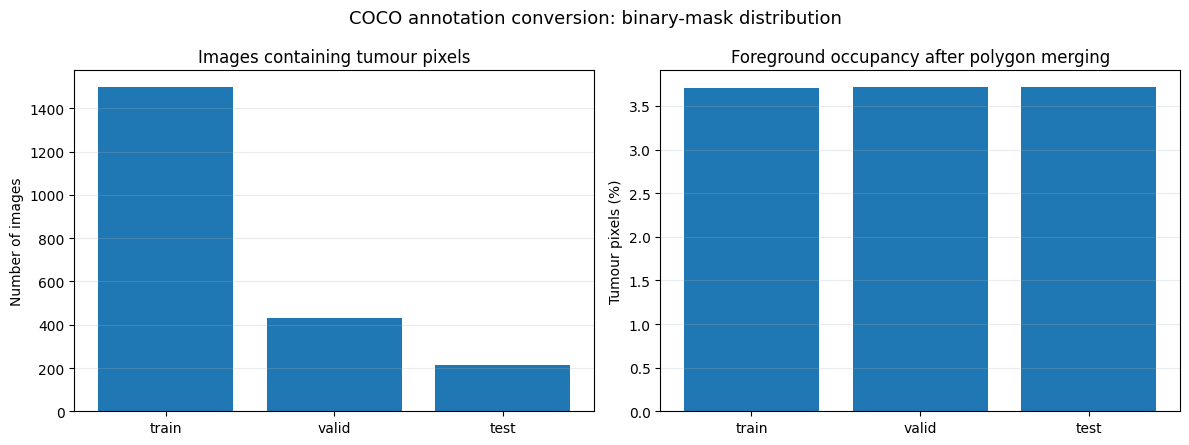

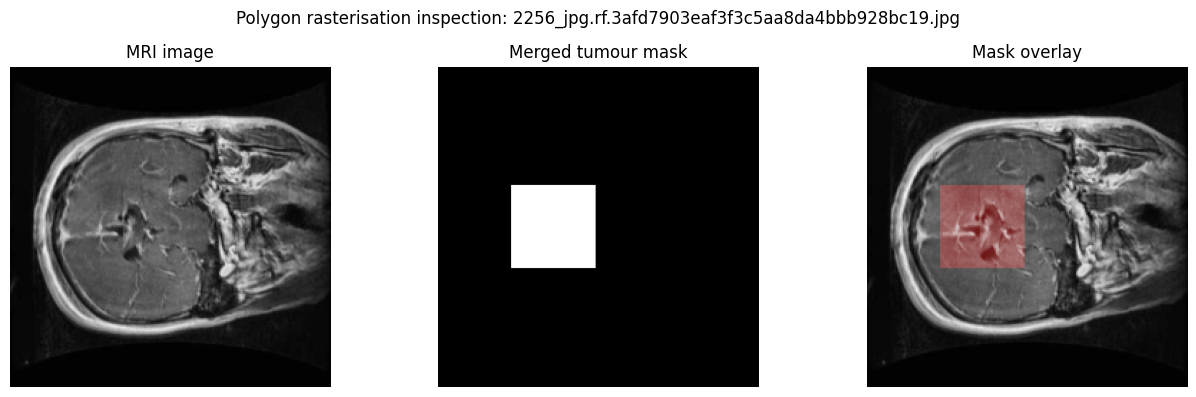

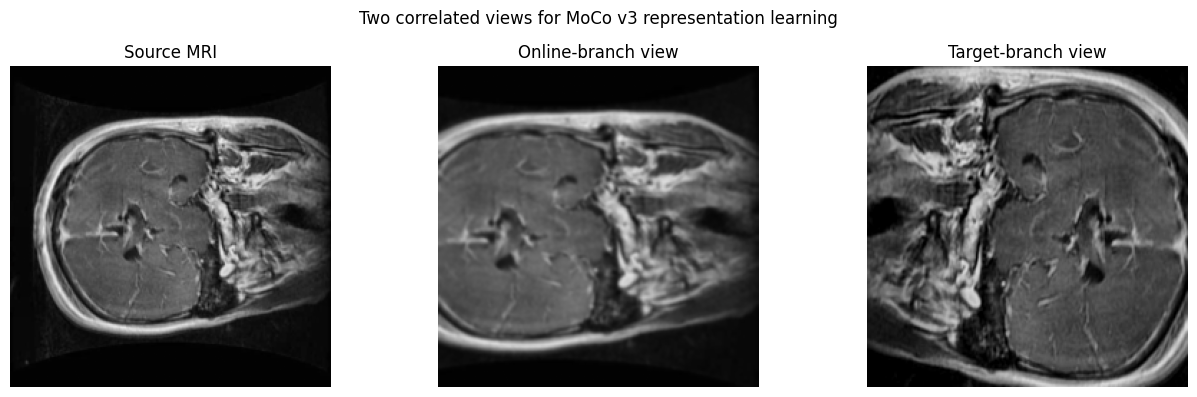

In [5]:

# ============================================================
# 5. Preliminary visualisations: masks and paired MoCo v3 views
# ============================================================

def denormalise_image(image_tensor):
    """Return a model input tensor as a displayable RGB NumPy array."""
    mean = torch.tensor(IMAGENET_MEAN).reshape(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).reshape(3, 1, 1)
    image = image_tensor.detach().cpu() * std + mean
    return image.clamp(0.0, 1.0).permute(1, 2, 0).numpy()

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(mask_statistics["split"], mask_statistics["images_with_tumour"])
axes[0].set_title("Images containing tumour pixels")
axes[0].set_ylabel("Number of images")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(mask_statistics["split"], mask_statistics["tumour_pixels_percent"])
axes[1].set_title("Foreground occupancy after polygon merging")
axes[1].set_ylabel("Tumour pixels (%)")
axes[1].grid(axis="y", alpha=0.25)

figure.suptitle("COCO annotation conversion: binary-mask distribution", fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "01_mask_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

positive_index = next(
    (index for index in range(len(train_display_dataset))
     if train_display_dataset[index][1].sum().item() > 0),
    0,
)

image, mask, file_name = train_display_dataset[positive_index]
original = denormalise_image(image)
mask_array = mask.numpy()

overlay = original.copy()
overlay[..., 0] = np.maximum(overlay[..., 0], mask_array.astype(float))
overlay = 0.62 * original + 0.38 * overlay

figure, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(original)
axes[0].set_title("MRI image")
axes[1].imshow(mask_array, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Merged tumour mask")
axes[2].imshow(overlay)
axes[2].set_title("Mask overlay")
for axis in axes:
    axis.axis("off")
figure.suptitle(f"Polygon rasterisation inspection: {file_name}", fontsize=12)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "02_coco_mask_overlay.png", dpi=180, bbox_inches="tight")
plt.show()

view_one, view_two = moco_dataset[positive_index]
figure, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(original)
axes[0].set_title("Source MRI")
axes[1].imshow(denormalise_image(view_one))
axes[1].set_title("Online-branch view")
axes[2].imshow(denormalise_image(view_two))
axes[2].set_title("Target-branch view")
for axis in axes:
    axis.axis("off")
figure.suptitle("Two correlated views for MoCo v3 representation learning", fontsize=12)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "03_mocov3_augmented_views.png", dpi=180, bbox_inches="tight")
plt.show()


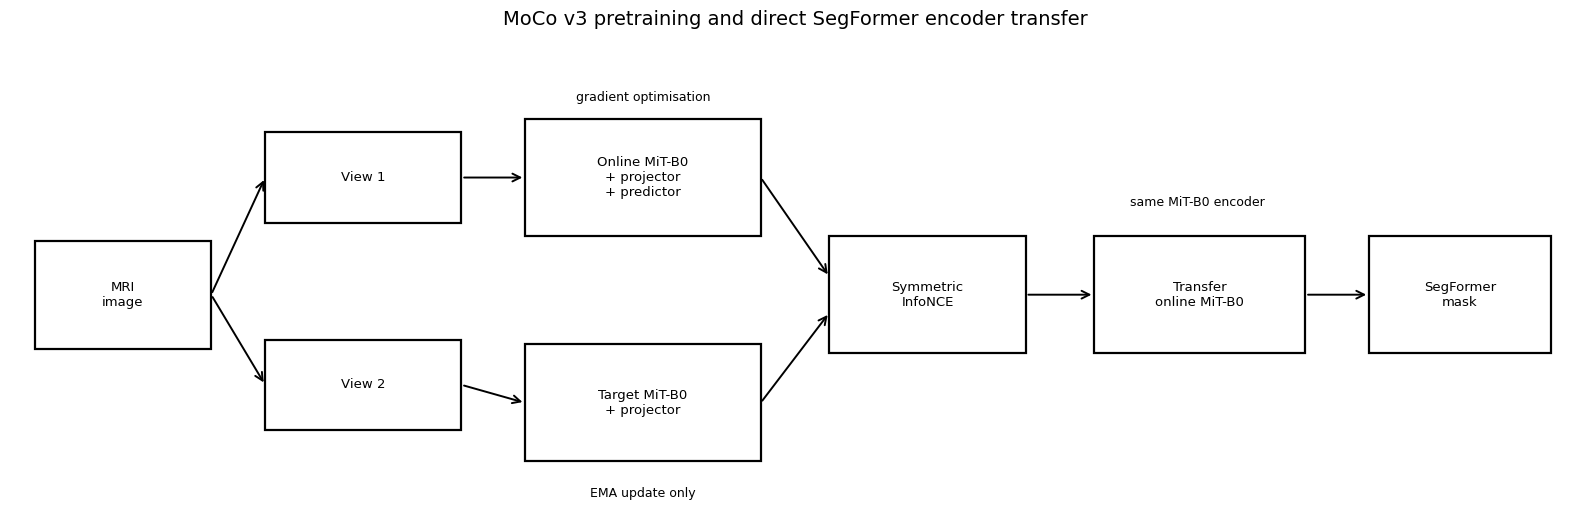

In [6]:

# ============================================================
# 6. Workflow figure: MoCo v3 with direct MiT-B0 transfer
# ============================================================

figure, axis = plt.subplots(figsize=(16, 5.4))
axis.set_xlim(0, 16)
axis.set_ylim(0, 5.4)
axis.axis("off")

workflow_boxes = [
    (0.25, 1.9, 1.8, 1.2, "MRI\nimage"),
    (2.6, 3.3, 2.0, 1.0, "View 1"),
    (2.6, 1.0, 2.0, 1.0, "View 2"),
    (5.25, 3.15, 2.4, 1.3, "Online MiT-B0\n+ projector\n+ predictor"),
    (5.25, 0.65, 2.4, 1.3, "Target MiT-B0\n+ projector"),
    (8.35, 1.85, 2.0, 1.3, "Symmetric\nInfoNCE"),
    (11.05, 1.85, 2.15, 1.3, "Transfer\nonline MiT-B0"),
    (13.85, 1.85, 1.85, 1.3, "SegFormer\nmask"),
]

for x, y, width, height, text in workflow_boxes:
    axis.add_patch(Rectangle((x, y), width, height, fill=False, linewidth=1.6))
    axis.text(x + width / 2, y + height / 2, text, ha="center", va="center", fontsize=9.5)

links = [
    ((2.05, 2.5), (2.6, 3.8)),
    ((2.05, 2.5), (2.6, 1.5)),
    ((4.6, 3.8), (5.25, 3.8)),
    ((4.6, 1.5), (5.25, 1.3)),
    ((7.65, 3.8), (8.35, 2.7)),
    ((7.65, 1.3), (8.35, 2.3)),
    ((10.35, 2.5), (11.05, 2.5)),
    ((13.2, 2.5), (13.85, 2.5)),
]
for start, finish in links:
    axis.add_patch(FancyArrowPatch(start, finish, arrowstyle="->", mutation_scale=14, linewidth=1.4))

axis.text(6.45, 4.65, "gradient optimisation", ha="center", fontsize=9)
axis.text(6.45, 0.25, "EMA update only", ha="center", fontsize=9)
axis.text(12.1, 3.48, "same MiT-B0 encoder", ha="center", fontsize=9)

axis.set_title("MoCo v3 pretraining and direct SegFormer encoder transfer", fontsize=14)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "04_mocov3_segformer_workflow.png", dpi=180, bbox_inches="tight")
plt.show()



## MoCo v3 with the MiT-B0 encoder

The online branch receives gradients through a projector and predictor. The target branch is a momentum copy of the encoder and projector, and is not directly optimised. For two views \(x_1\) and \(x_2\), a symmetric contrastive objective is used:

\[
\mathcal{L}
=
\frac{1}{2}
\left[
\ell\big(q(x_1), k(x_2)\big)
+
\ell\big(q(x_2), k(x_1)\big)
\right].
\]

For each query in a mini-batch, the target representation of the corresponding second view forms the positive pair; the remaining target representations in that mini-batch provide negative comparisons.


In [7]:

# ============================================================
# 7. SegFormer MiT-B0 construction with offline fallback
# ============================================================

def mit_b0_random_config(num_labels=NUM_CLASSES):
    """
    Provide the canonical MiT-B0 dimensional structure if pretrained model
    files cannot be downloaded in the Kaggle runtime.
    """
    return SegformerConfig(
        num_channels=3,
        num_encoder_blocks=4,
        depths=[2, 2, 2, 2],
        sr_ratios=[8, 4, 2, 1],
        hidden_sizes=[32, 64, 160, 256],
        patch_sizes=[7, 3, 3, 3],
        strides=[4, 2, 2, 2],
        num_attention_heads=[1, 2, 5, 8],
        mlp_ratios=[4, 4, 4, 4],
        decoder_hidden_size=256,
        num_labels=num_labels,
        semantic_loss_ignore_index=255,
        id2label={0: "background", 1: "tumour"},
        label2id={"background": 0, "tumour": 1},
    )

def create_initial_mit_encoder():
    """
    Use the published MiT-B0 encoder when it is accessible. Kaggle notebooks
    may run without internet access; in that setting the architecture is
    instantiated with randomly initialised MiT-B0 parameters.
    """
    if LOAD_PRETRAINED_MIT_WHEN_AVAILABLE:
        try:
            encoder = SegformerModel.from_pretrained(MIT_MODEL_ID)
            print(f"Loaded pretrained encoder: {MIT_MODEL_ID}")
            return encoder, "pretrained nvidia/mit-b0"
        except Exception as error:
            print(f"Pretrained MiT-B0 could not be loaded: {type(error).__name__}: {error}")
            print("Falling back to randomly initialised MiT-B0 for MoCo v3 pretraining.")

    encoder = SegformerModel(mit_b0_random_config())
    return encoder, "randomly initialised MiT-B0"

def final_feature_map(segformer_backbone, pixel_values):
    """
    Return the final spatial MiT feature map. This helper is tolerant of
    transformer-library variants that return either BCHW features or token
    sequences at the last encoder stage.
    """
    output = segformer_backbone(pixel_values=pixel_values, return_dict=True)
    feature = output.last_hidden_state

    if feature.ndim == 4:
        return feature

    if feature.ndim == 3:
        batch_size, token_count, channels = feature.shape
        side = int(round(math.sqrt(token_count)))
        if side * side != token_count:
            raise RuntimeError("Cannot reshape the final token sequence into a spatial feature map.")
        return feature.transpose(1, 2).reshape(batch_size, channels, side, side)

    raise RuntimeError(f"Unsupported SegFormer feature shape: {tuple(feature.shape)}")

def pooled_mit_features(segformer_backbone, pixel_values):
    """Pool the final MiT spatial representation into one vector per MRI."""
    feature_map = final_feature_map(segformer_backbone, pixel_values)
    return F.adaptive_avg_pool2d(feature_map, output_size=1).flatten(1)


In [8]:

# ============================================================
# 8. MoCo v3 architecture and AMP-stable symmetric loss
# ============================================================

class ProjectionMLP(nn.Module):
    """Three-layer MoCo v3 projection head with BatchNorm stabilisation."""
    def __init__(self, input_dim, hidden_dim=MOCO_MLP_HIDDEN_DIM, output_dim=MOCO_PROJECTION_DIM):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, output_dim, bias=False),
            nn.BatchNorm1d(output_dim, affine=False),
        )

    def forward(self, features):
        return self.layers(features)

class PredictionMLP(nn.Module):
    """Online-branch predictor used only for query representations."""
    def __init__(self, input_dim=MOCO_PROJECTION_DIM, hidden_dim=MOCO_MLP_HIDDEN_DIM):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, embeddings):
        return self.layers(embeddings)

class MoCoV3SegFormer(nn.Module):
    """
    MoCo v3 whose representation backbone is precisely the MiT-B0 encoder
    required later by SegFormer semantic segmentation.
    """
    def __init__(self, momentum=MOCO_MOMENTUM_BASE, temperature=MOCO_TEMPERATURE):
        super().__init__()
        self.momentum = momentum
        self.temperature = temperature

        self.online_encoder, self.initialisation_source = create_initial_mit_encoder()
        feature_dimension = self.online_encoder.config.hidden_sizes[-1]

        self.online_projector = ProjectionMLP(feature_dimension)
        self.online_predictor = PredictionMLP()

        self.target_encoder = copy.deepcopy(self.online_encoder)
        self.target_projector = copy.deepcopy(self.online_projector)

        for parameter in self.target_encoder.parameters():
            parameter.requires_grad = False
        for parameter in self.target_projector.parameters():
            parameter.requires_grad = False

    @torch.no_grad()
    def update_target_network(self, momentum=None):
        """Exponential moving-average update for target encoder and projector."""
        momentum = self.momentum if momentum is None else momentum

        for online_parameter, target_parameter in zip(
            self.online_encoder.parameters(), self.target_encoder.parameters()
        ):
            target_parameter.data.mul_(momentum).add_(
                online_parameter.data, alpha=1.0 - momentum
            )

        for online_parameter, target_parameter in zip(
            self.online_projector.parameters(), self.target_projector.parameters()
        ):
            target_parameter.data.mul_(momentum).add_(
                online_parameter.data, alpha=1.0 - momentum
            )

    def encode_online(self, images):
        features = pooled_mit_features(self.online_encoder, images)
        projected = self.online_projector(features)
        return self.online_predictor(projected)

    @torch.no_grad()
    def encode_target(self, images):
        features = pooled_mit_features(self.target_encoder, images)
        return self.target_projector(features)

def cross_view_infonce_float32(query, target, temperature):
    """
    AMP-stable in-batch contrastive loss.

    Model forward passes may run under AMP. Before constructing the similarity
    matrix, representations are promoted to float32. The positive key for row i
    is target row i; other rows are negatives.
    """
    with disable_autocast_for_contrastive(query):
        query = F.normalize(query.float(), dim=1)
        target = F.normalize(target.float(), dim=1)

        logits = torch.matmul(query, target.transpose(0, 1)) / float(temperature)
        targets = torch.arange(logits.size(0), device=logits.device, dtype=torch.long)
        loss = F.cross_entropy(logits, targets)

        cosine_similarity = logits.detach() * float(temperature)
        positive = cosine_similarity.diagonal()
        negative_mask = ~torch.eye(
            cosine_similarity.size(0), dtype=torch.bool, device=cosine_similarity.device
        )
        negative = cosine_similarity[negative_mask]

    return loss, positive, negative

def mocov3_forward_and_loss(model, first_view, second_view):
    """Compute symmetric MoCo v3 loss between two augmented MRI views."""
    with autocast_context():
        online_first = model.encode_online(first_view)
        online_second = model.encode_online(second_view)

        with torch.no_grad():
            target_first = model.encode_target(first_view)
            target_second = model.encode_target(second_view)

    loss_one, positive_one, negative_one = cross_view_infonce_float32(
        online_first, target_second, model.temperature
    )
    loss_two, positive_two, negative_two = cross_view_infonce_float32(
        online_second, target_first, model.temperature
    )

    symmetric_loss = 0.5 * (loss_one + loss_two)
    positives = torch.cat([positive_one, positive_two])
    negatives = torch.cat([negative_one, negative_two])
    return symmetric_loss, positives, negatives


In [9]:

# ============================================================
# 9. MoCo v3 smoke test and ten-epoch pretraining
# ============================================================

mocov3_model = MoCoV3SegFormer().to(DEVICE)
print(f"MoCo v3 encoder initialisation: {mocov3_model.initialisation_source}")

# Retain the pre-MoCo encoder state for later t-SNE and response-map comparison.
initial_encoder_state = copy.deepcopy(mocov3_model.online_encoder.state_dict())
torch.save(initial_encoder_state, CHECKPOINT_DIR / "initial_mit_b0_encoder.pth")

online_parameters = (
    list(mocov3_model.online_encoder.parameters())
    + list(mocov3_model.online_projector.parameters())
    + list(mocov3_model.online_predictor.parameters())
)
mocov3_optimizer = torch.optim.AdamW(
    online_parameters, lr=MOCO_LR, weight_decay=WEIGHT_DECAY
)
mocov3_scaler = create_grad_scaler()

# ------------------------------------------------------------
# Smoke test: catches shape, loss precision, and AMP issues
# before the ten-epoch pretraining loop starts.
# ------------------------------------------------------------
smoke_first, smoke_second = next(iter(moco_loader))
smoke_first = smoke_first.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
smoke_second = smoke_second.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()

mocov3_model.train()
smoke_loss, smoke_positive, smoke_negative = mocov3_forward_and_loss(
    mocov3_model, smoke_first, smoke_second
)

assert smoke_loss.dtype == torch.float32, "MoCo v3 contrastive loss must remain float32."
assert torch.isfinite(smoke_loss).item(), "MoCo v3 smoke test produced a non-finite loss."
assert smoke_positive.numel() == 2 * smoke_first.size(0)
assert smoke_negative.numel() > 0, "MoCo v3 needs at least two samples per mini-batch."

print(f"MoCo v3 loss smoke test passed: {smoke_loss.item():.4f} (float32 objective)")

# ------------------------------------------------------------
# Ten epochs of self-supervised representation learning.
# ------------------------------------------------------------
mocov3_history = []
total_steps = max(1, MOCO_EPOCHS * len(moco_loader))
global_step = 0

for epoch in range(1, MOCO_EPOCHS + 1):
    mocov3_model.train()
    losses, positive_scores, negative_scores = [], [], []

    progress = tqdm(moco_loader, desc=f"MoCo v3 epoch {epoch:02d}/{MOCO_EPOCHS}", leave=True)
    for first_view, second_view in progress:
        first_view = first_view.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        second_view = second_view.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()

        mocov3_optimizer.zero_grad(set_to_none=True)
        loss, positives, negatives = mocov3_forward_and_loss(
            mocov3_model, first_view, second_view
        )

        mocov3_scaler.scale(loss).backward()
        mocov3_scaler.step(mocov3_optimizer)
        mocov3_scaler.update()

        # Cosine schedule raises the target momentum progressively towards 1.0.
        cosine_value = (math.cos(math.pi * global_step / total_steps) + 1.0) / 2.0
        current_momentum = 1.0 - (1.0 - MOCO_MOMENTUM_BASE) * cosine_value
        mocov3_model.update_target_network(momentum=current_momentum)
        global_step += 1

        losses.append(float(loss.detach().cpu()))
        positive_scores.extend(positives.detach().float().cpu().numpy().tolist())

        # Sampling reduces memory use in the final diagnostic distribution.
        sampled_negative = negatives[: min(512, negatives.numel())]
        negative_scores.extend(sampled_negative.detach().float().cpu().numpy().tolist())

        progress.set_postfix(loss=f"{np.mean(losses):.4f}", m=f"{current_momentum:.5f}")

    mocov3_history.append({
        "epoch": epoch,
        "contrastive_loss": float(np.mean(losses)),
        "positive_similarity": float(np.mean(positive_scores)),
        "negative_similarity": float(np.mean(negative_scores)),
        "target_momentum": float(current_momentum),
    })

    if epoch == MOCO_EPOCHS:
        final_positive_scores = np.asarray(positive_scores)
        final_negative_scores = np.asarray(negative_scores)

mocov3_history_df = pd.DataFrame(mocov3_history)
mocov3_history_df.to_csv(METRIC_DIR / "mocov3_pretraining_history.csv", index=False)

torch.save(
    {
        "online_encoder": mocov3_model.online_encoder.state_dict(),
        "online_projector": mocov3_model.online_projector.state_dict(),
        "online_predictor": mocov3_model.online_predictor.state_dict(),
        "initialisation_source": mocov3_model.initialisation_source,
        "epochs": MOCO_EPOCHS,
        "temperature": MOCO_TEMPERATURE,
        "base_momentum": MOCO_MOMENTUM_BASE,
    },
    CHECKPOINT_DIR / "mocov3_mit_b0_online_encoder.pth",
)

mocov3_history_df


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/14.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerModel LOAD REPORT from: nvidia/mit-b0
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded pretrained encoder: nvidia/mit-b0


...

MoCo v3 epoch 07/10:   0%|          | 0/93 [00:00<?, ?it/s]

MoCo v3 epoch 08/10:   0%|          | 0/93 [00:00<?, ?it/s]

MoCo v3 epoch 09/10:   0%|          | 0/93 [00:00<?, ?it/s]

MoCo v3 epoch 10/10:   0%|          | 0/93 [00:00<?, ?it/s]

,epoch,contrastive_loss,positive_similarity,negative_similarity,target_momentum
0,1,1.946199,0.251626,-0.015879,0.990240
1,2,0.961935,0.612071,-0.038591,0.990945
2,3,0.634548,0.747032,-0.047337,0.992047
3,4,0.499760,0.802493,-0.051600,0.993439
4,5,0.430044,0.831946,-0.053571,0.994983
5,6,0.382673,0.849106,-0.054964,0.996529
6,7,0.357144,0.859349,-0.055605,0.997925
7,8,0.354008,0.863476,-0.055672,0.999035
8,9,0.328523,0.871714,-0.056778,0.999750
9,10,0.324639,0.873597,-0.056801,1.000000


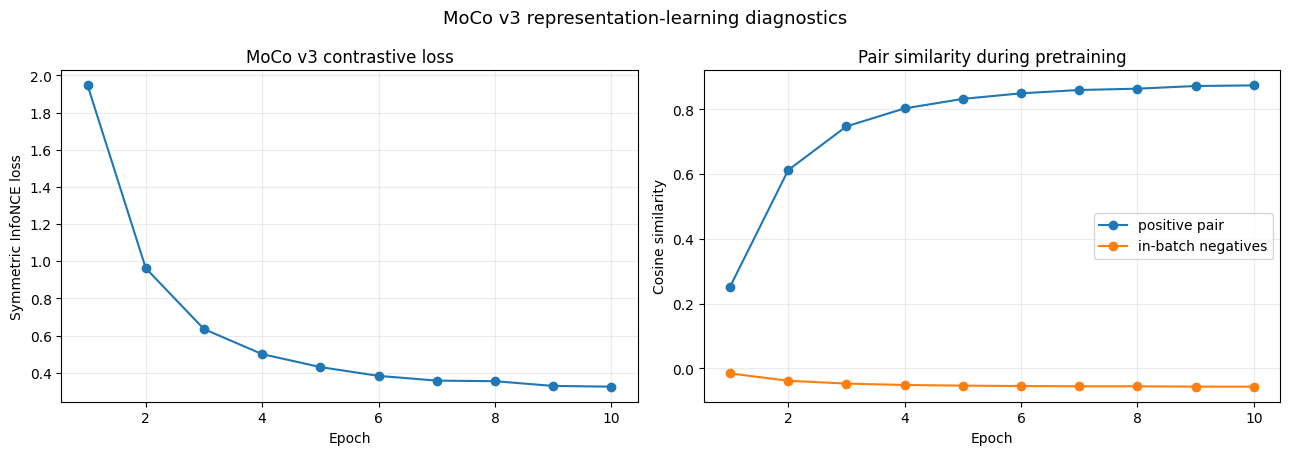

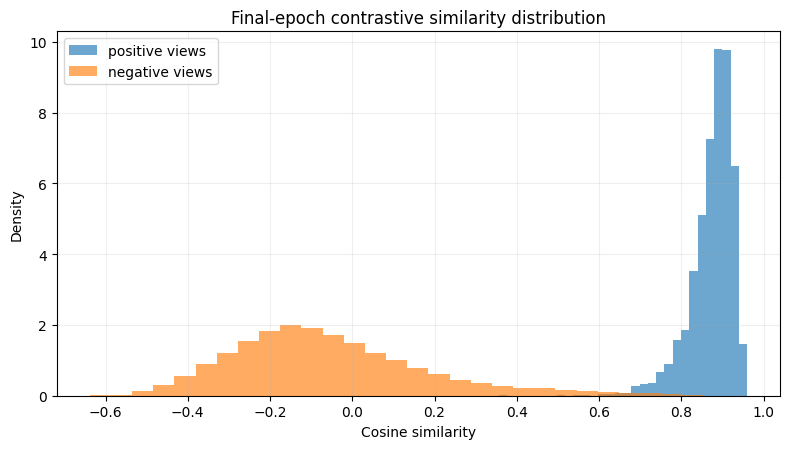

The paired-view distribution should move towards greater similarity than the negative distribution when the encoder learns stable MRI representations.


In [10]:

# ============================================================
# 10. MoCo v3 learning diagnostics
# ============================================================

figure, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].plot(mocov3_history_df["epoch"], mocov3_history_df["contrastive_loss"], marker="o")
axes[0].set_title("MoCo v3 contrastive loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Symmetric InfoNCE loss")
axes[0].grid(alpha=0.25)

axes[1].plot(
    mocov3_history_df["epoch"], mocov3_history_df["positive_similarity"],
    marker="o", label="positive pair"
)
axes[1].plot(
    mocov3_history_df["epoch"], mocov3_history_df["negative_similarity"],
    marker="o", label="in-batch negatives"
)
axes[1].set_title("Pair similarity during pretraining")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Cosine similarity")
axes[1].legend()
axes[1].grid(alpha=0.25)

figure.suptitle("MoCo v3 representation-learning diagnostics", fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "05_mocov3_learning_curves.png", dpi=180, bbox_inches="tight")
plt.show()

figure, axis = plt.subplots(figsize=(8, 4.6))
axis.hist(final_positive_scores, bins=30, density=True, alpha=0.65, label="positive views")
axis.hist(final_negative_scores, bins=30, density=True, alpha=0.65, label="negative views")
axis.set_title("Final-epoch contrastive similarity distribution")
axis.set_xlabel("Cosine similarity")
axis.set_ylabel("Density")
axis.legend()
axis.grid(alpha=0.20)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "06_mocov3_similarity_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

print(
    "The paired-view distribution should move towards greater similarity than "
    "the negative distribution when the encoder learns stable MRI representations."
)



## Direct encoder transfer into SegFormer-B0

The online MiT-B0 encoder trained in MoCo v3 is inserted directly into the segmentation model. No ResNet or other auxiliary encoder is introduced. The decoder receives hierarchical MiT features and predicts two semantic classes. Because SegFormer logits are generated at a lower spatial resolution, they are bilinearly upsampled to the binary-mask resolution before loss and metric computation.


In [11]:

# ============================================================
# 11. SegFormer-B0 model construction and direct encoder transfer
# ============================================================

def create_segmentation_model_from_mocov3(trained_mocov3):
    """
    Build a two-class SegFormer and copy the MoCo v3-trained online MiT encoder
    into the identical SegFormer encoder module.
    """
    segmentation_config = copy.deepcopy(trained_mocov3.online_encoder.config)
    segmentation_config.num_labels = NUM_CLASSES
    segmentation_config.semantic_loss_ignore_index = 255
    segmentation_config.id2label = {0: "background", 1: "tumour"}
    segmentation_config.label2id = {"background": 0, "tumour": 1}

    segmentation_model = SegformerForSemanticSegmentation(segmentation_config)
    transfer_result = segmentation_model.segformer.encoder.load_state_dict(
        trained_mocov3.online_encoder.encoder.state_dict(),
        strict=True,
    )
    print("MoCo v3 online MiT-B0 encoder transferred directly into SegFormer-B0.")
    print(transfer_result)
    return segmentation_model

segmentation_model = create_segmentation_model_from_mocov3(mocov3_model).to(DEVICE)

class CrossEntropyDiceLoss(nn.Module):
    """Cross-entropy plus foreground Dice loss for imbalanced binary masks."""
    def __init__(self, dice_weight=1.0, epsilon=1e-6):
        super().__init__()
        self.dice_weight = dice_weight
        self.epsilon = epsilon

    def forward(self, logits, targets):
        cross_entropy = F.cross_entropy(logits, targets)

        foreground_probability = torch.softmax(logits.float(), dim=1)[:, 1]
        foreground_target = (targets == 1).float()

        intersection = (foreground_probability * foreground_target).sum(dim=(1, 2))
        denominator = foreground_probability.sum(dim=(1, 2)) + foreground_target.sum(dim=(1, 2))
        dice_score = (2.0 * intersection + self.epsilon) / (denominator + self.epsilon)
        dice_loss = 1.0 - dice_score.mean()

        total_loss = cross_entropy + self.dice_weight * dice_loss
        return total_loss, cross_entropy.detach(), dice_loss.detach()

criterion = CrossEntropyDiceLoss(dice_weight=1.0)
segmentation_optimizer = torch.optim.AdamW(
    segmentation_model.parameters(),
    lr=SEGMENTATION_LR,
    weight_decay=WEIGHT_DECAY,
)
segmentation_scaler = create_grad_scaler()

def update_metric_counts(predicted_mask, target_mask):
    """Calculate pixel counts needed for foreground Dice, IoU, and accuracy."""
    prediction = predicted_mask == 1
    target = target_mask == 1

    true_positive = int((prediction & target).sum().item())
    false_positive = int((prediction & ~target).sum().item())
    false_negative = int((~prediction & target).sum().item())
    correct = int((prediction == target).sum().item())
    total = int(target.numel())
    return true_positive, false_positive, false_negative, correct, total

def finalise_metrics(tp, fp, fn, correct, total, epsilon=1e-7):
    return {
        "dice": (2.0 * tp + epsilon) / (2.0 * tp + fp + fn + epsilon),
        "iou": (tp + epsilon) / (tp + fp + fn + epsilon),
        "pixel_accuracy": correct / max(1, total),
    }

def run_segmentation_epoch(model, loader, optimizer=None, scaler=None, description="evaluation"):
    """Run one SegFormer epoch with logits resized to the ground-truth mask grid."""
    training = optimizer is not None
    model.train(training)

    losses = []
    tp = fp = fn = correct = total = 0

    progress = tqdm(loader, desc=description, leave=False)
    for images, masks, _ in progress:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        masks = masks.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with autocast_context():
                model_output = model(pixel_values=images, return_dict=True)
                resized_logits = F.interpolate(
                    model_output.logits,
                    size=masks.shape[-2:],
                    mode="bilinear",
                    align_corners=False,
                )
                loss, _, _ = criterion(resized_logits, masks)

            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        losses.append(float(loss.detach().cpu()))
        predictions = resized_logits.detach().argmax(dim=1)
        counts = update_metric_counts(predictions, masks.detach())
        tp += counts[0]
        fp += counts[1]
        fn += counts[2]
        correct += counts[3]
        total += counts[4]

        progress.set_postfix(loss=f"{np.mean(losses):.4f}")

    metrics = finalise_metrics(tp, fp, fn, correct, total)
    metrics["loss"] = float(np.mean(losses))
    return metrics


MoCo v3 online MiT-B0 encoder transferred directly into SegFormer-B0.
<All keys matched successfully>


In [12]:

# ============================================================
# 12. Ten-epoch SegFormer-B0 fine-tuning and held-out testing
# ============================================================

segmentation_history = []
best_validation_dice = -1.0
best_model_path = CHECKPOINT_DIR / "best_mocov3_segformer_binary_segmentation.pth"

for epoch in range(1, SEGMENTATION_EPOCHS + 1):
    training_metrics = run_segmentation_epoch(
        segmentation_model,
        train_loader,
        optimizer=segmentation_optimizer,
        scaler=segmentation_scaler,
        description=f"SegFormer train {epoch:02d}/{SEGMENTATION_EPOCHS}",
    )
    validation_metrics = run_segmentation_epoch(
        segmentation_model,
        valid_loader,
        description=f"SegFormer valid {epoch:02d}/{SEGMENTATION_EPOCHS}",
    )

    epoch_record = {"epoch": epoch}
    for key, value in training_metrics.items():
        epoch_record[f"train_{key}"] = value
    for key, value in validation_metrics.items():
        epoch_record[f"valid_{key}"] = value
    segmentation_history.append(epoch_record)

    print(
        f"Epoch {epoch:02d}: "
        f"train loss={training_metrics['loss']:.4f}, train Dice={training_metrics['dice']:.4f} | "
        f"valid loss={validation_metrics['loss']:.4f}, valid Dice={validation_metrics['dice']:.4f}, "
        f"valid IoU={validation_metrics['iou']:.4f}, "
        f"valid accuracy={validation_metrics['pixel_accuracy']:.4f}"
    )

    if validation_metrics["dice"] > best_validation_dice:
        best_validation_dice = validation_metrics["dice"]
        torch.save(
            {
                "model_state_dict": segmentation_model.state_dict(),
                "epoch": epoch,
                "validation_metrics": validation_metrics,
                "encoder_source": "MoCo v3 online MiT-B0 encoder",
            },
            best_model_path,
        )

segmentation_history_df = pd.DataFrame(segmentation_history)
segmentation_history_df.to_csv(METRIC_DIR / "segformer_training_history.csv", index=False)

best_checkpoint = torch.load(best_model_path, map_location=DEVICE)
segmentation_model.load_state_dict(best_checkpoint["model_state_dict"])

test_metrics = run_segmentation_epoch(
    segmentation_model,
    test_loader,
    description="Held-out test evaluation",
)
test_metrics_df = pd.DataFrame([test_metrics])
test_metrics_df.to_csv(METRIC_DIR / "test_metrics.csv", index=False)

print("\nHeld-out test results from the best validation checkpoint")
print(test_metrics_df.round(4).to_string(index=False))
print(f"\nSaved checkpoint: {best_model_path}")


SegFormer train 01/10:   0%|          | 0/251 [00:00<?, ?it/s]

SegFormer valid 01/10:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 01: train loss=0.7397, train Dice=0.5066 | valid loss=0.4618, valid Dice=0.6578, valid IoU=0.4901, valid accuracy=0.9704


SegFormer train 02/10:   0%|          | 0/251 [00:00<?, ?it/s]

SegFormer valid 02/10:   0%|          | 0/72 [00:00<?, ?it/s]

...

SegFormer train 10/10:   0%|          | 0/251 [00:00<?, ?it/s]

SegFormer valid 10/10:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 10: train loss=0.2872, train Dice=0.7874 | valid loss=0.3213, valid Dice=0.7636, valid IoU=0.6177, valid accuracy=0.9815


Held-out test evaluation:   0%|          | 0/36 [00:00<?, ?it/s]


Held-out test results from the best validation checkpoint
  dice    iou  pixel_accuracy   loss
0.7635 0.6174           0.983 0.3164

Saved checkpoint: /kaggle/working/mocov3_segformer_brain_tumour/checkpoints/best_mocov3_segformer_binary_segmentation.pth


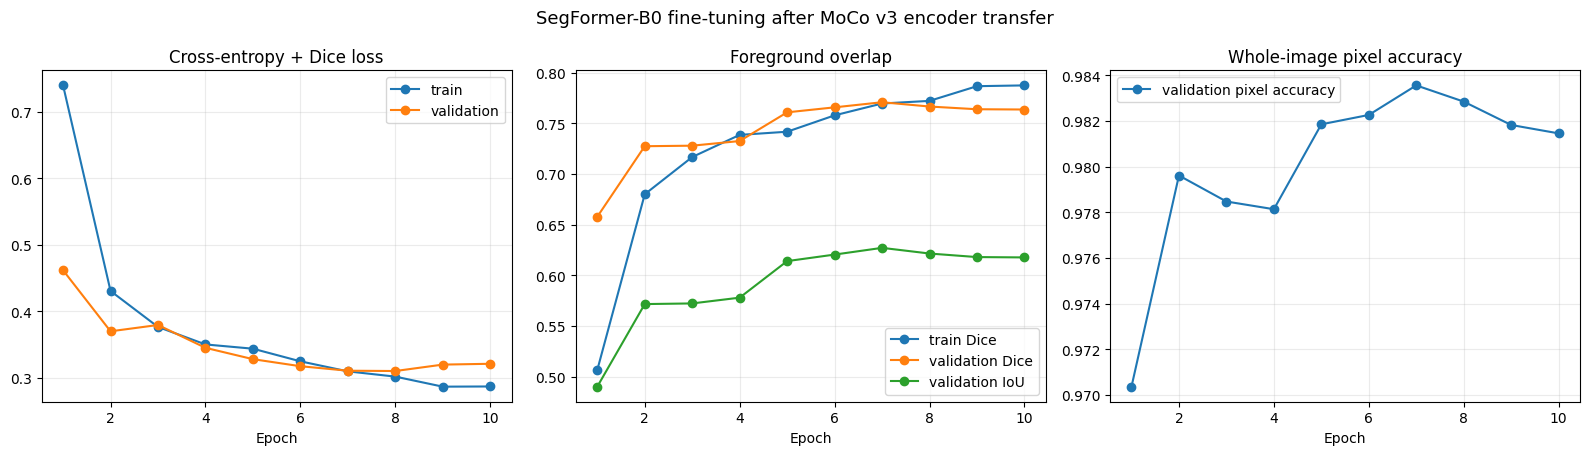

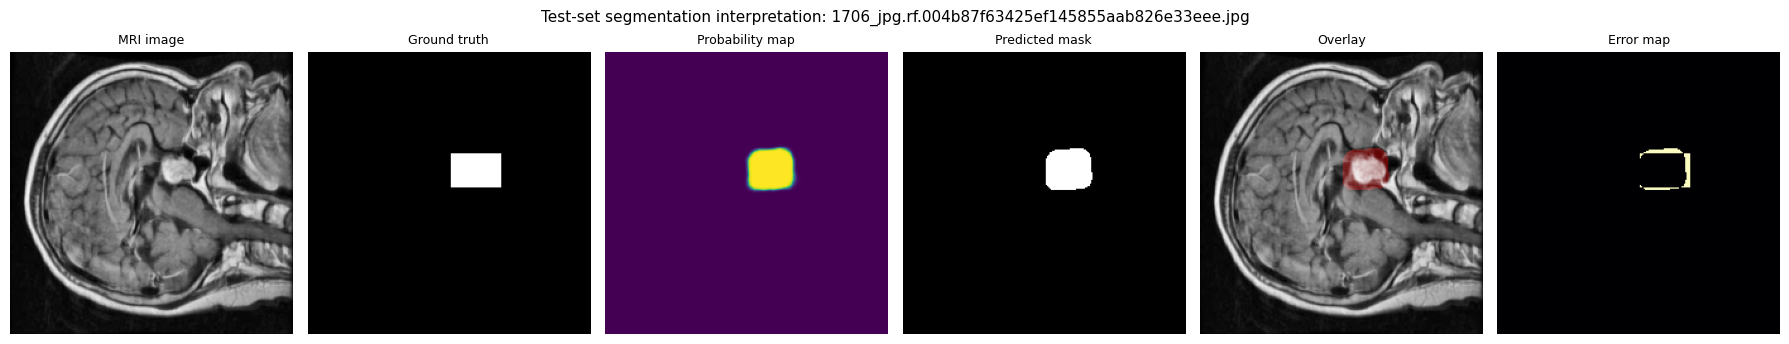

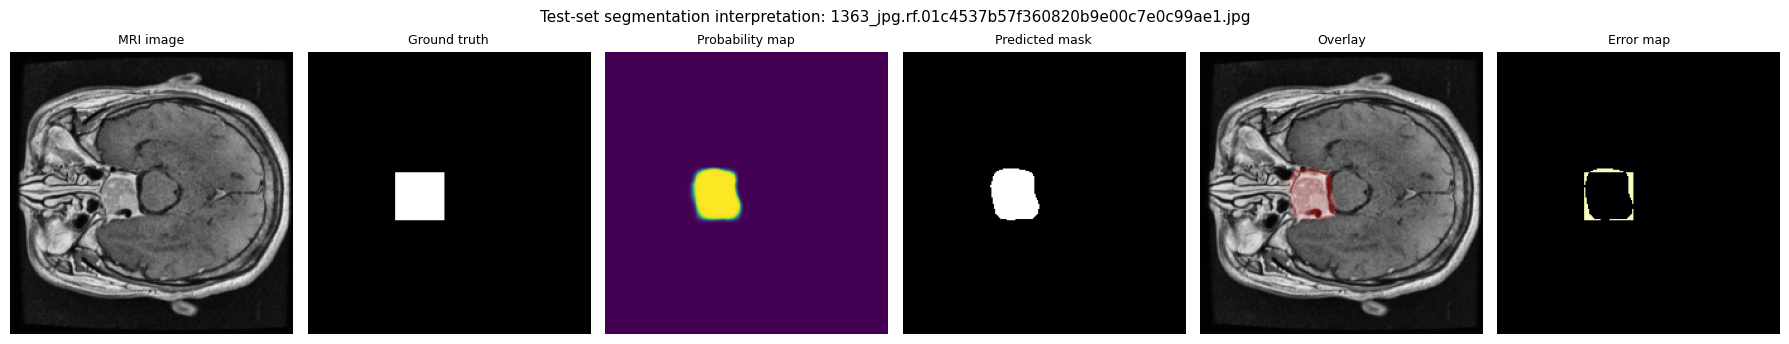

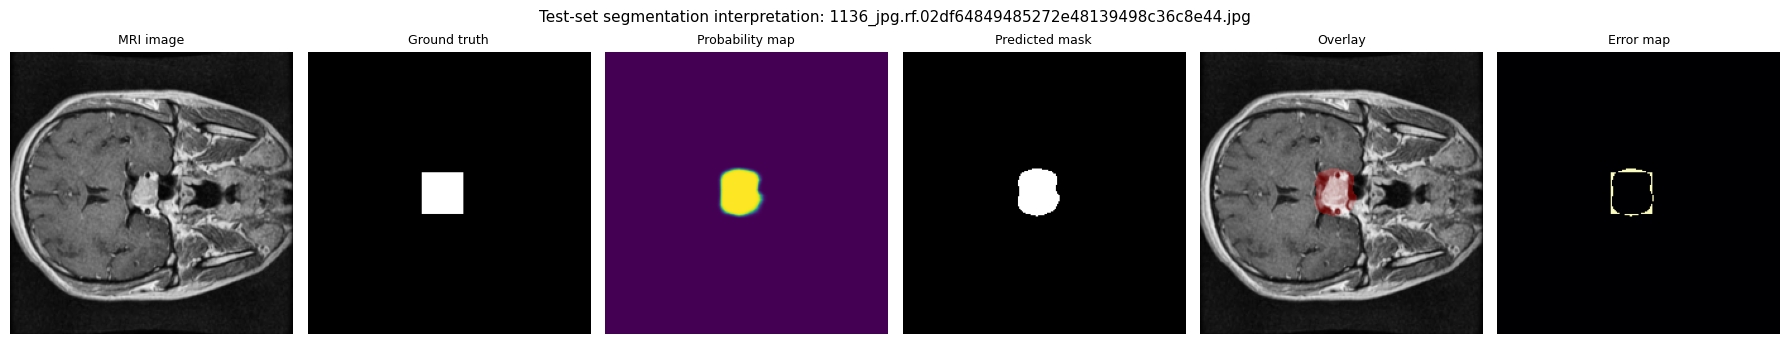

In [13]:

# ============================================================
# 13. Segmentation curves and qualitative prediction panels
# ============================================================

figure, axes = plt.subplots(1, 3, figsize=(16, 4.6))

axes[0].plot(segmentation_history_df["epoch"], segmentation_history_df["train_loss"], marker="o", label="train")
axes[0].plot(segmentation_history_df["epoch"], segmentation_history_df["valid_loss"], marker="o", label="validation")
axes[0].set_title("Cross-entropy + Dice loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(segmentation_history_df["epoch"], segmentation_history_df["train_dice"], marker="o", label="train Dice")
axes[1].plot(segmentation_history_df["epoch"], segmentation_history_df["valid_dice"], marker="o", label="validation Dice")
axes[1].plot(segmentation_history_df["epoch"], segmentation_history_df["valid_iou"], marker="o", label="validation IoU")
axes[1].set_title("Foreground overlap")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.25)

axes[2].plot(
    segmentation_history_df["epoch"],
    segmentation_history_df["valid_pixel_accuracy"],
    marker="o",
    label="validation pixel accuracy",
)
axes[2].set_title("Whole-image pixel accuracy")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(alpha=0.25)

figure.suptitle("SegFormer-B0 fine-tuning after MoCo v3 encoder transfer", fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "07_segmentation_training_curves.png", dpi=180, bbox_inches="tight")
plt.show()

@torch.inference_mode()
def infer_single_image(model, dataset, index):
    image, ground_truth, file_name = dataset[index]
    input_batch = image.unsqueeze(0).to(DEVICE).contiguous()

    with autocast_context():
        logits = model(pixel_values=input_batch, return_dict=True).logits
        logits = F.interpolate(
            logits, size=ground_truth.shape[-2:],
            mode="bilinear", align_corners=False
        )

    probability = torch.softmax(logits.float(), dim=1)[0, 1].cpu()
    predicted_mask = (probability >= 0.5).long()
    return image, ground_truth, probability, predicted_mask, file_name

positive_test_indices = [
    index for index in range(len(test_dataset))
    if test_dataset[index][1].sum().item() > 0
][:3]
if not positive_test_indices:
    positive_test_indices = list(range(min(3, len(test_dataset))))

for example_number, index in enumerate(positive_test_indices, start=1):
    image, ground_truth, probability, prediction, file_name = infer_single_image(
        segmentation_model, test_dataset, index
    )

    image_array = denormalise_image(image)
    ground_truth_array = ground_truth.numpy()
    probability_array = probability.numpy()
    prediction_array = prediction.numpy()
    error_array = (prediction != ground_truth).numpy().astype(float)

    predicted_overlay = image_array.copy()
    predicted_overlay[..., 0] = np.maximum(predicted_overlay[..., 0], prediction_array)
    predicted_overlay = 0.62 * image_array + 0.38 * predicted_overlay

    figure, axes = plt.subplots(1, 6, figsize=(18, 3.5))
    display_panels = [
        (image_array, "MRI image", None),
        (ground_truth_array, "Ground truth", "gray"),
        (probability_array, "Probability map", "viridis"),
        (prediction_array, "Predicted mask", "gray"),
        (predicted_overlay, "Overlay", None),
        (error_array, "Error map", "magma"),
    ]

    for axis, (panel, title, colourmap) in zip(axes, display_panels):
        if colourmap is None:
            axis.imshow(panel)
        else:
            axis.imshow(panel, cmap=colourmap, vmin=0, vmax=1)
        axis.set_title(title, fontsize=9)
        axis.axis("off")

    figure.suptitle(f"Test-set segmentation interpretation: {file_name}", fontsize=11)
    figure.tight_layout()
    figure.savefig(
        FIGURE_DIR / f"08_prediction_panel_{example_number}.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()



## Representation-space interpretation

The final analysis compares encoder features at three points:

1. **Initial MiT-B0 encoder:** immediately before MoCo v3 training; this may be pretrained when the checkpoint is available or randomly initialised under offline fallback.
2. **After MoCo v3:** the online MiT-B0 encoder after contrastive learning.
3. **After segmentation fine-tuning:** the encoder embedded in the trained SegFormer model.

The response maps indicate where feature activation is concentrated, while t-SNE provides a two-dimensional neighbourhood visualisation. The t-SNE panels should be treated as explanatory visual evidence rather than as a quantitative performance metric.


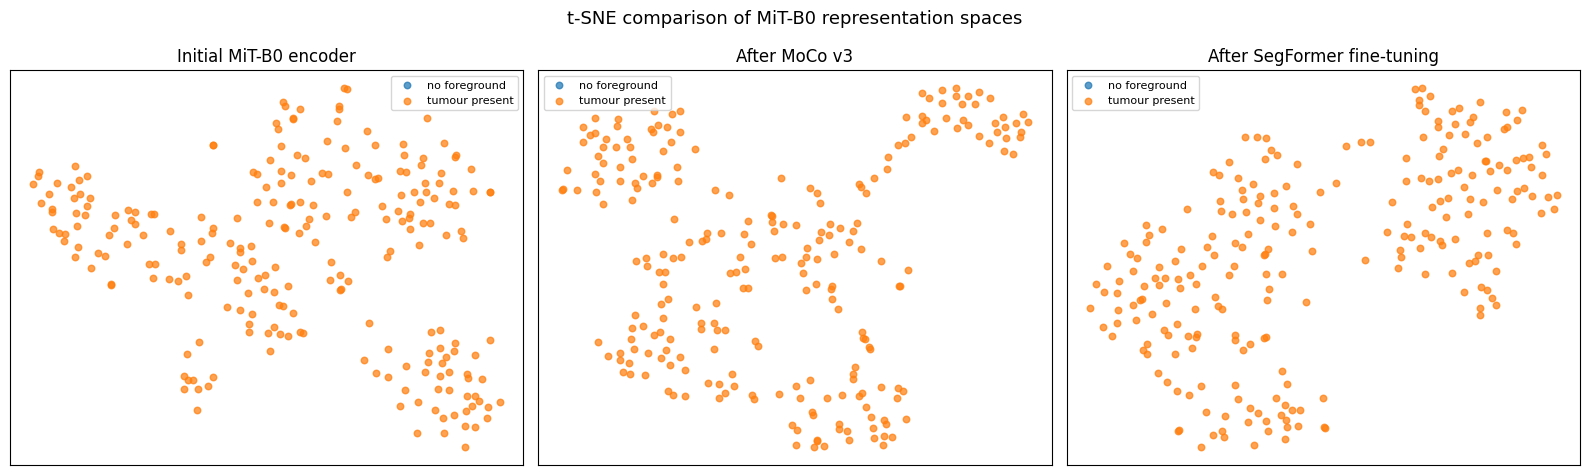

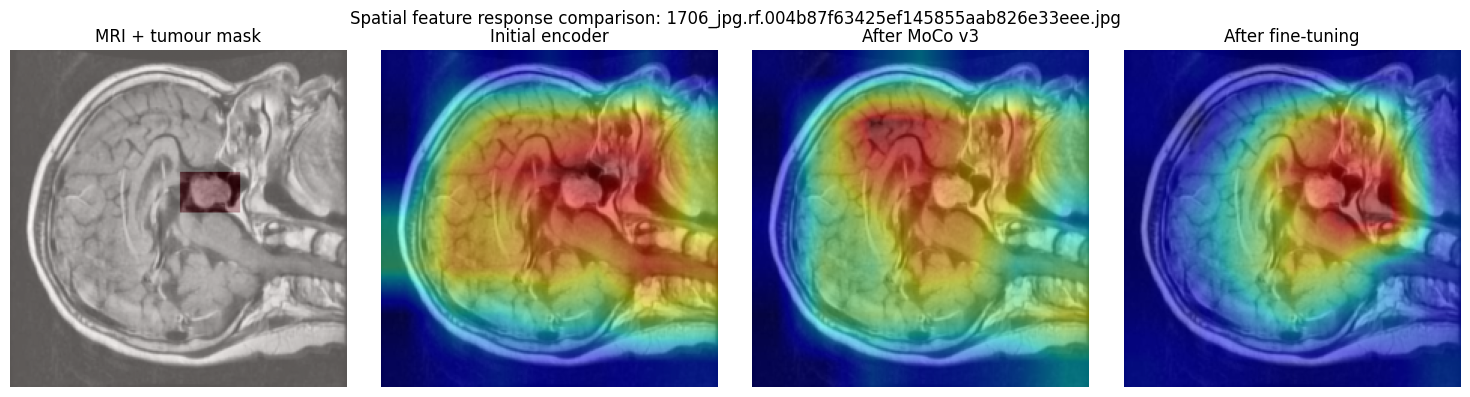

In [14]:

# ============================================================
# 14. Spatial response maps and t-SNE features across three stages
# ============================================================

# Reconstruct the initial pre-MoCo encoder with exactly the stored configuration.
initial_encoder = SegformerModel(copy.deepcopy(mocov3_model.online_encoder.config)).to(DEVICE)
initial_encoder.load_state_dict(initial_encoder_state)
initial_encoder.eval()

mocov3_encoder = copy.deepcopy(mocov3_model.online_encoder).to(DEVICE)
mocov3_encoder.eval()

finetuned_encoder = segmentation_model.segformer
finetuned_encoder.eval()

@torch.inference_mode()
def collect_stage_features(encoder, loader, maximum_samples=240):
    """
    Extract pooled final-stage features and a teaching label:
    whether the MRI has foreground tumour pixels.
    """
    features = []
    labels = []

    for images, masks, _ in loader:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        vectors = pooled_mit_features(encoder, images).float().cpu().numpy()
        foreground_present = (masks.flatten(1).sum(dim=1) > 0).long().numpy()

        features.append(vectors)
        labels.append(foreground_present)

        if sum(part.shape[0] for part in labels) >= maximum_samples:
            break

    return (
        np.concatenate(features, axis=0)[:maximum_samples],
        np.concatenate(labels, axis=0)[:maximum_samples],
    )

initial_features, feature_labels = collect_stage_features(initial_encoder, feature_loader)
mocov3_features, _ = collect_stage_features(mocov3_encoder, feature_loader)
finetuned_features, _ = collect_stage_features(finetuned_encoder, feature_loader)

def form_tsne_embedding(features):
    standardised = StandardScaler().fit_transform(features)
    sample_count = standardised.shape[0]
    perplexity = max(2, min(30, sample_count // 4, sample_count - 1))
    return TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=SEED,
    ).fit_transform(standardised)

tsne_stages = [
    form_tsne_embedding(initial_features),
    form_tsne_embedding(mocov3_features),
    form_tsne_embedding(finetuned_features),
]
stage_titles = [
    "Initial MiT-B0 encoder",
    "After MoCo v3",
    "After SegFormer fine-tuning",
]

figure, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for axis, stage_coordinates, title in zip(axes, tsne_stages, stage_titles):
    for class_id, class_name in [(0, "no foreground"), (1, "tumour present")]:
        selected = feature_labels == class_id
        axis.scatter(
            stage_coordinates[selected, 0],
            stage_coordinates[selected, 1],
            s=22,
            alpha=0.72,
            label=class_name,
        )
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.legend(fontsize=8)

figure.suptitle("t-SNE comparison of MiT-B0 representation spaces", fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "09_tsne_three_stage_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

response_index = positive_test_indices[0] if positive_test_indices else 0
response_image, response_mask, response_name = test_dataset[response_index]
response_batch = response_image.unsqueeze(0).to(DEVICE).contiguous()

@torch.inference_mode()
def response_map(encoder, input_batch, target_size):
    feature_grid = final_feature_map(encoder, input_batch)
    activation = feature_grid.float().abs().mean(dim=1, keepdim=True)
    activation = F.interpolate(
        activation, size=target_size, mode="bilinear", align_corners=False
    )[0, 0]
    activation = activation - activation.min()
    activation = activation / (activation.max() + 1e-7)
    return activation.cpu().numpy()

initial_response = response_map(initial_encoder, response_batch, response_mask.shape[-2:])
mocov3_response = response_map(mocov3_encoder, response_batch, response_mask.shape[-2:])
finetuned_response = response_map(finetuned_encoder, response_batch, response_mask.shape[-2:])

response_base_image = denormalise_image(response_image)

figure, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(response_base_image)
axes[0].imshow(response_mask.numpy(), cmap="Reds", alpha=0.35, vmin=0, vmax=1)
axes[0].set_title("MRI + tumour mask")

for axis, spatial_map, title in zip(
    axes[1:],
    [initial_response, mocov3_response, finetuned_response],
    ["Initial encoder", "After MoCo v3", "After fine-tuning"],
):
    axis.imshow(response_base_image)
    axis.imshow(spatial_map, cmap="jet", alpha=0.48, vmin=0, vmax=1)
    axis.set_title(title)

for axis in axes:
    axis.axis("off")

figure.suptitle(f"Spatial feature response comparison: {response_name}", fontsize=12)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "10_spatial_feature_responses.png", dpi=180, bbox_inches="tight")
plt.show()


In [15]:

# ============================================================
# 15. Save a concise experiment report
# ============================================================

experiment_summary = {
    "course": "CSE 438: Digital Image Processing",
    "instructor": "Dr Md Rifat Ahmmad Rashid",
    "pipeline": "MoCo v3 pretraining of MiT-B0 followed by SegFormer-B0 binary semantic segmentation",
    "dataset_root": str(DATA_ROOT),
    "classes": {"0": "background", "1": "tumour region"},
    "device": str(DEVICE),
    "amp_enabled": bool(AMP_ENABLED),
    "encoder_initialisation": mocov3_model.initialisation_source,
    "mocov3_epochs": MOCO_EPOCHS,
    "segmentation_epochs": SEGMENTATION_EPOCHS,
    "mocov3_parameters": {
        "temperature": MOCO_TEMPERATURE,
        "base_momentum": MOCO_MOMENTUM_BASE,
        "projection_dimension": MOCO_PROJECTION_DIM,
    },
    "best_validation_dice": float(best_validation_dice),
    "test_metrics": {key: float(value) for key, value in test_metrics.items()},
    "output_locations": {
        "figures": str(FIGURE_DIR),
        "metrics": str(METRIC_DIR),
        "checkpoints": str(CHECKPOINT_DIR),
    },
}

with open(OUTPUT_DIR / "experiment_summary.json", "w", encoding="utf-8") as file:
    json.dump(experiment_summary, file, indent=2)

print(json.dumps(experiment_summary, indent=2))
print("\nSummary comment:")
print(
    "This notebook pretrains the same MiT-B0 encoder subsequently used by SegFormer. "
    "The segmentation findings should be interpreted through overlap metrics, error maps, "
    "response maps, and feature-space behaviour rather than pixel accuracy alone."
)


{
  "course": "CSE 438: Digital Image Processing",
  "instructor": "Dr Md Rifat Ahmmad Rashid",
  "pipeline": "MoCo v3 pretraining of MiT-B0 followed by SegFormer-B0 binary semantic segmentation",
  "dataset_root": "/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation",
  "classes": {
    "0": "background",
    "1": "tumour region"
  },
  "device": "cuda",
  "amp_enabled": true,
  "encoder_initialisation": "pretrained nvidia/mit-b0",
  "mocov3_epochs": 10,
  "segmentation_epochs": 10,
  "mocov3_parameters": {
    "temperature": 0.2,
    "base_momentum": 0.99,
    "projection_dimension": 256
  },
  "best_validation_dice": 0.7708233599168892,
  "test_metrics": {
    "dice": 0.7634566371795921,
    "iou": 0.6174119405228847,
    "pixel_accuracy": 0.9830085540757001,
    "loss": 0.3164443005290296
  },
  "output_locations": {
    "figures": "/kaggle/working/mocov3_segformer_brain_tumour/figures",
    "metrics": "/kaggle/working/mocov3_segformer_brain_tumour/metri


## References

1. Chen, X., Xie, S., and He, K. (2021). *An Empirical Study of Training Self-Supervised Vision Transformers*. Proceedings of ICCV, 9640–9649.  
2. Xie, E., Wang, W., Yu, Z., Anandkumar, A., Alvarez, J. M., and Luo, P. (2021). *SegFormer: Simple and Efficient Design for Semantic Segmentation with Transformers*. Advances in Neural Information Processing Systems, 34, 12077–12090.  
3. He, K., Fan, H., Wu, Y., Xie, S., and Girshick, R. (2020). *Momentum Contrast for Unsupervised Visual Representation Learning*. Proceedings of CVPR, 9729–9738.
